In [1]:
def master_function(standard_arg, *args, **kwargs):
    print(f"Standard: {standard_arg}")
    print(f"Args: {args}")
    print(f"Kwargs: {kwargs}")

master_function("Hello", 1, 2, 3, color="blue", size="large")

Standard: Hello
Args: (1, 2, 3)
Kwargs: {'color': 'blue', 'size': 'large'}


In [ ]:
#TWO FORMS OF INTEGRATION: CLOSED AND OPEN

#NEWTON COTES IS A CLOSED MERTHOD
APPLIES TRAPEZOIDAL RULE TO EACH SEGMENT. HAS FIRST ORDER ACCURACY, THAT MEANS ANY EQUATION THAT'S FIRST ORDER, OUR TRAPZOID IS PERFECT


#trapezoidal rule
C0 = 0.08 # mL/(min * mm)
tau = 2.5 # min
lam = 0.6 #mm
rc = 0.01 #mm
R = 1.5 #mm
L = 30 #mm
global t #min
t = 6

def C(r, t):
  return C0 * (1-np.exp(-t/tau)) * np.exp(-r/lam)

def trapezoid(a, b, n):
  h = (b-a)/n #h in this case is step size
  integral = 0

  #integration at our bounds. 
  integral += 0.5*h * integrand(a)
  integral += 0.5*h * integrand(b)

  for i in range(1, n):
    x = i*h + a
    integral += h * integrand(x)
  return integral

#the integrand is essentially our function. 
def integrand(r):
  return C(r, t) * 2 * np.pi * r * L

val_trap = trapezoid(rc, R, 18)
print(f"Trapezoidal result: {val_trap:.4f} mL O₂/min")

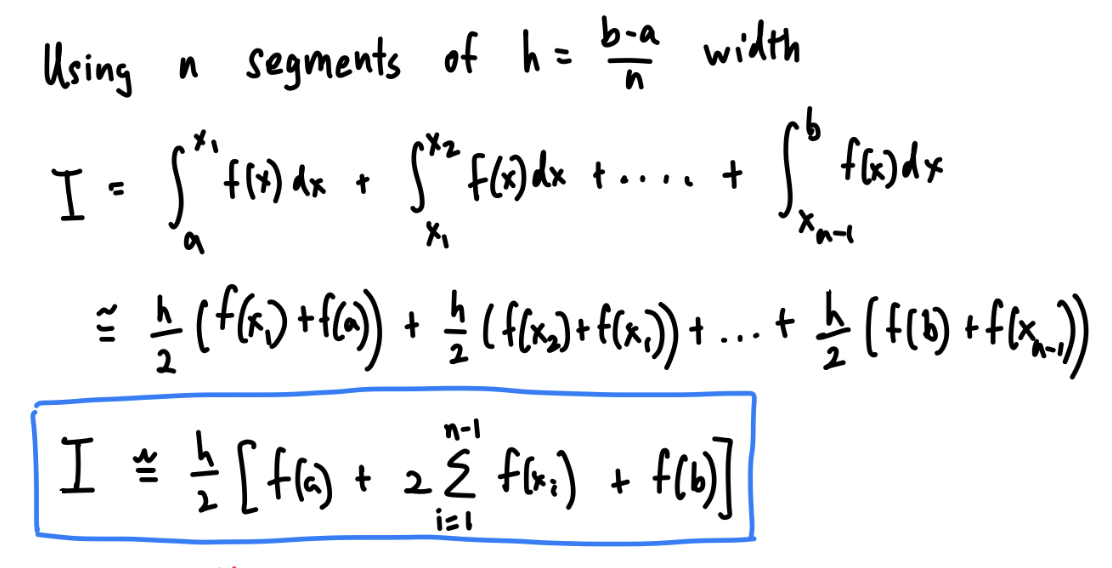

In [ ]:
#WE USE SIMPSONS RULE FOR HIGHER ORDER POLYNOMIALS
#SIMPSONS 1/3 RULE: 2ND ORDER
#SIMPSONS 3/8 RULE: 3RD ORDER

#because we're not using quadractic interpolation, we need three points. 2 boundaries and one cetner point. 

def simpsons_one_third(a, b, n):
  if n % 2 != 0:
    raise ValueError("n must be even for Simpson's 1/3")

  h = (b-a)/n
  integral = 0
  integral += 1/3 * h * integrand(a)
  integral += 1/3 * h * integrand(b)

  for i in range(1, n, 2):
    x = i*h + a
    integral += 4/3 * h * integrand(x)

  for i in range(2, n-1, 2):
    x = i*h + a
    integral += 2/3 * h * integrand(x)

  return integral

def simpsons_three_eighth(a, b, n):
    if n % 3 != 0:
        raise ValueError("n must be a multiple of 3 for Simpson's 3/8")

    h = (b - a) / n

    integral = 0
    integral += integrand(a) + integrand(b)
    for i in range(1, n):
      x = i*h + a

      if i % 3 == 0:
        integral += 2 * integrand(x)
      else:
        integral += 3 * integrand(x)

    integral *= 3*h/8
    return integral

val_s13 = simpsons_one_third(rc, R, 18)
val_s38 = simpsons_three_eighth(rc, R, 18)

print(f"Simpson 1/3: {val_s13:.4f} mL O₂/min")
print(f"Simpson 3/8: {val_s38:.4f} mL O₂/min")

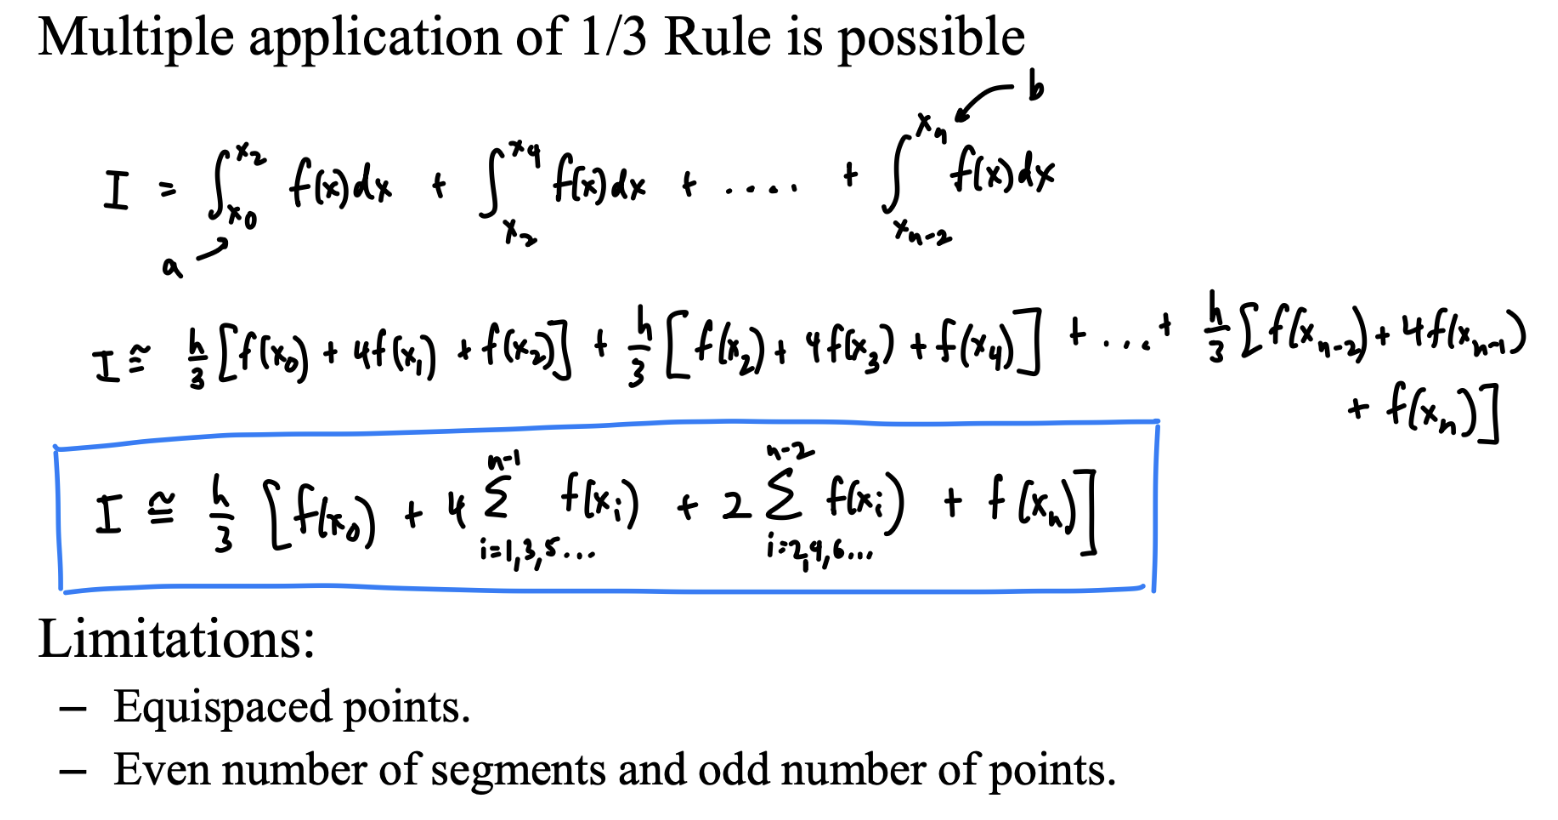
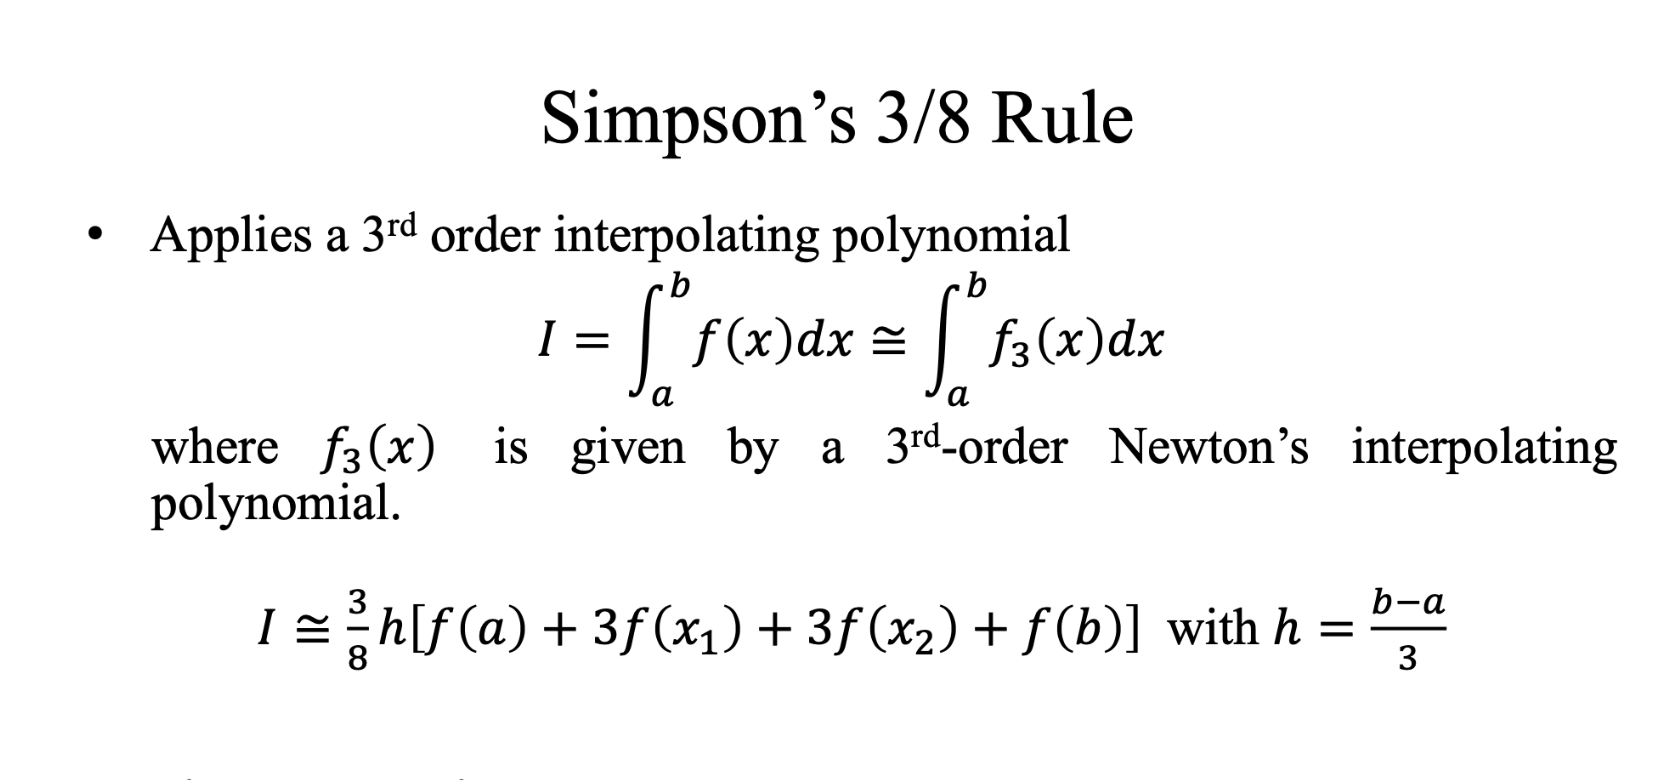

For simpsons rule, we can use richardson's extrpolation with a smaller step size to get ROMBERG INTEGRATION -> improves error to be O(h^4) copmared to O(h^2)



THERE'S ALSO QUADRATURE INTEGRATION METHODS. FOR NON EQUALLY SPACED POINTS
-> changes step ize based on local curvuture 

GAUSS QUADRATURE
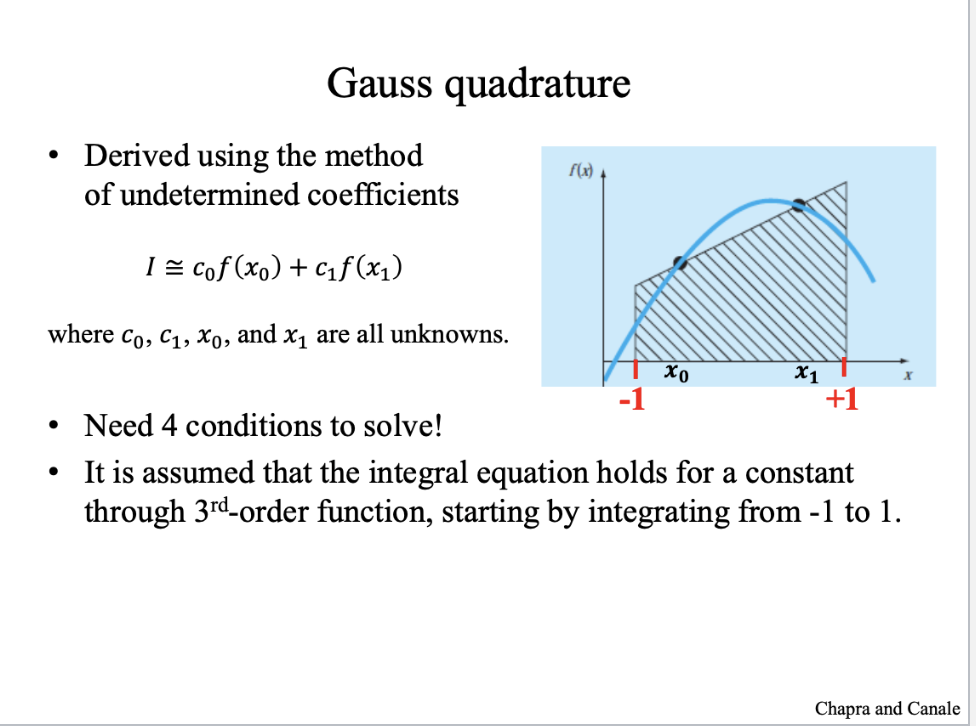
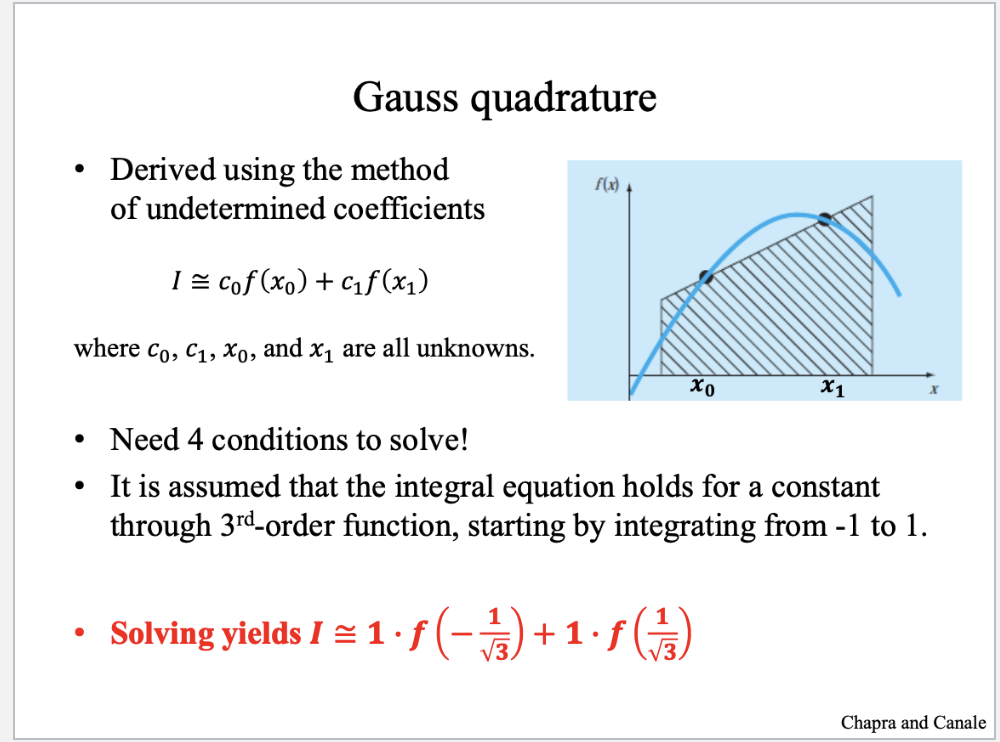

We can use a CHANGE OF VARIABELS to change our bounds against -1 to 1 

updating our constants->Co = (b+a)/2 , C1 = (b-a)/2

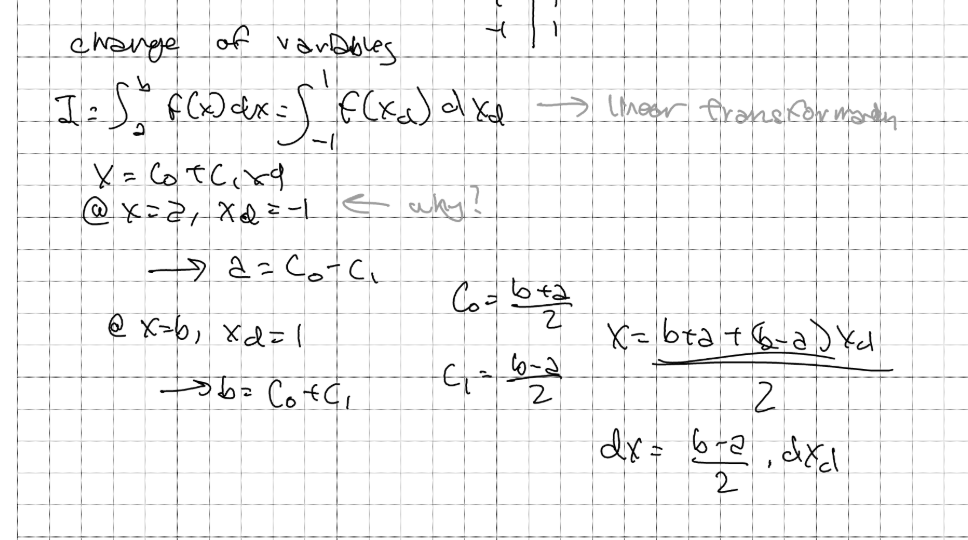

higher order guass drature with other consstants as well.



there are different types of Differential Equations: Initial or Boundary

IVP or BVP. 
IVP's are simpler. they provide starting points at each of the derivatives/orders at the SAME VALUE.

basically, we have differential equations, and we're using these methods to SOLVE FOR Y, the original equation.

solve IVP using taylor series:
    first order taylor series method is EULERS METHOD, error is order Oh^2
    HEUNS method - take two derivates at initial and end point and average the slopes. iterative method, uses the previous estiamte to improve the next method. 
    MIDPOINT: epplies uerles method at midpoint of the interval. 

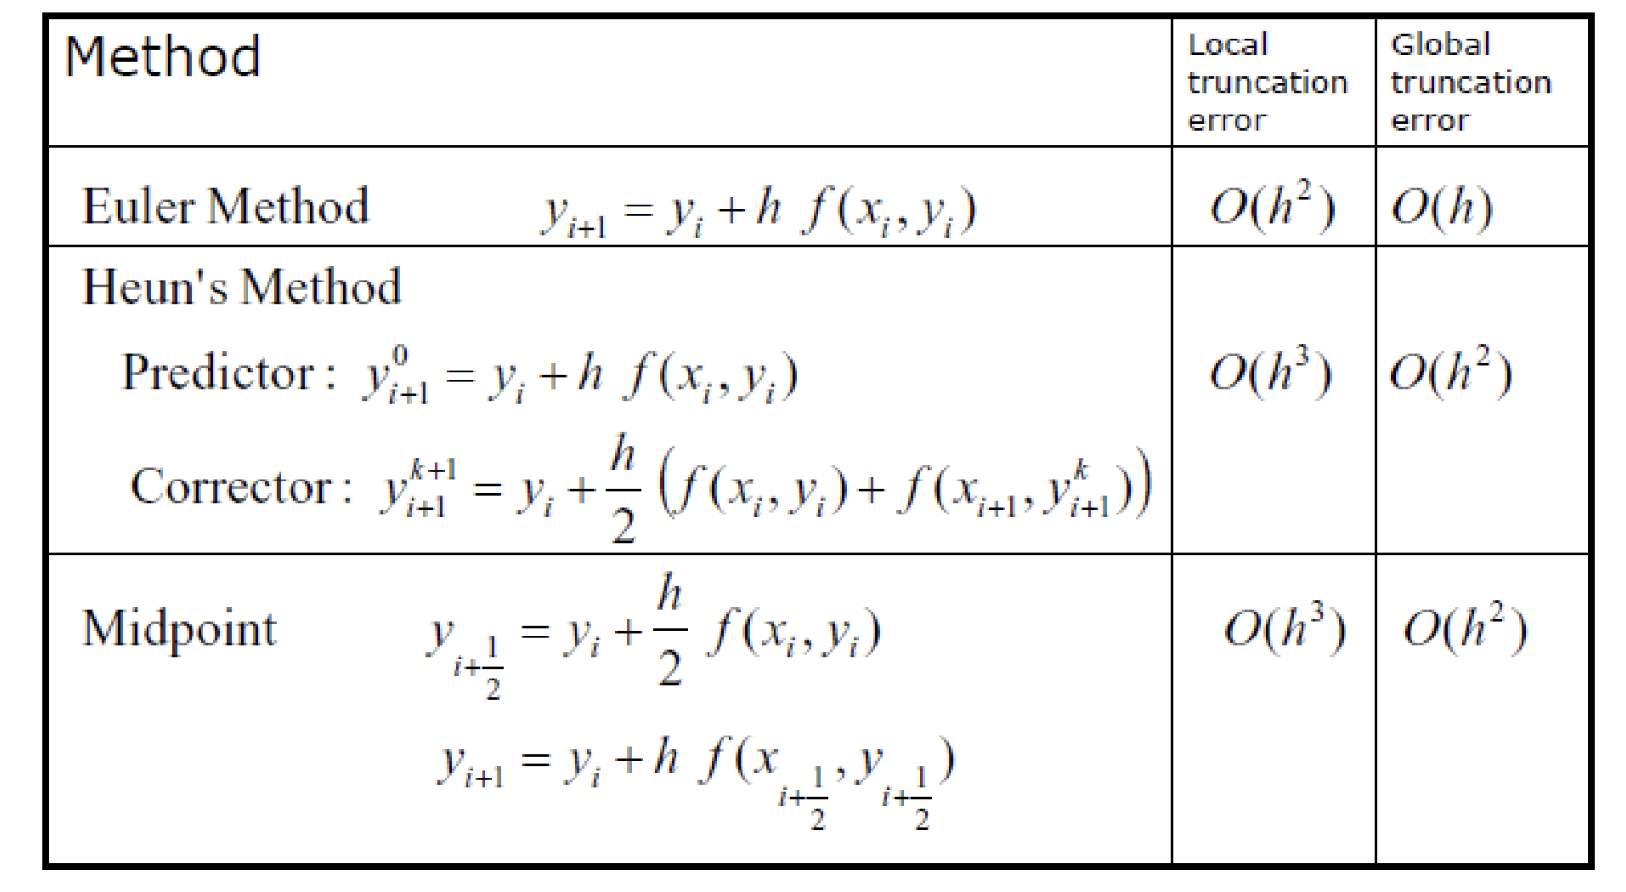

Another method is to use RUNGE-KUTTA METHODS

here, we use an "effective slope" over the interval (defined by the step size). this slope (phi) is definedby  a set of variables and constants

also, there's fourth order RK methods. 



In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. THE PHYSICS (The "Integrand" or Derivative) ---
def dh_dt(h, r_hole=0.3, r_tank=2.0, g=9.81):
    """Calculates the rate of change of height: dh/dt"""
    # Torricelli's Law: flow rate depends on the square root of height
    if h < 0: return 0  # Physical constraint: height cannot be negative
    ratio = (r_hole**2) / (r_tank**2)
    return -ratio * np.sqrt(2 * g * h)

# --- 2. THE MATH RECIPES (Step Functions) ---
# These functions only care about taking ONE single step forward.

def rk2_step(h, dt, f, method="heun"):
    """Generalized 2nd Order Runge-Kutta for one step."""
    k1 = f(h) # Slope at the start point
    
    # Choose weights based on the specific flavor of RK2
    if method == "heun":
        a1, a2, q11 = 0.5, 0.5, 1.0
    elif method == "midpoint":
        a1, a2, q11 = 0.0, 1.0, 0.5
    elif method == "ralston":
        a1, a2, q11 = 1/3, 2/3, 3/4
        
    # Predict a 'future' height using a fraction (q11) of the step
    h_pred = h + (k1 * q11 * dt)
    # Get the slope at that predicted height
    k2 = f(h_pred)
    
    # Return the new height using the weighted average of slopes
    return h + (a1*k1 + a2*k2) * dt

def rk4_step(h, dt, f):
    """Standard 4th Order Runge-Kutta for one step."""
    k1 = f(h)                      # Slope at start
    k2 = f(h + 0.5 * k1 * dt)      # Slope at midpoint (using k1)
    k3 = f(h + 0.5 * k2 * dt)      # Slope at midpoint (using k2)
    k4 = f(h + k3 * dt)            # Slope at end (using k3)
    
    # Combine slopes: middle slopes (k2, k3) get double weight
    return h + (1/6) * (k1 + 2*k2 + 2*k3 + k4) * dt

# --- 3. THE SOLVER (The Loop) ---
def solve_ode(h0, t_span, dt, step_func, **kwargs):
    """Manages the time loop and stores results."""
    t_start, t_end = t_span
    t_values = [t_start]
    h_values = [h0]
    
    h_current = h0
    t_current = t_start
    
    while t_current < t_end:
        # Ensure we don't overshoot the final time
        step = min(dt, t_end - t_current)
        
        # Calculate next height using the passed-in math recipe
        h_current = step_func(h_current, step, dh_dt, **kwargs)
        t_current += step
        
        h_values.append(h_current)
        t_values.append(t_current)
        
    return np.array(t_values), np.array(h_values)

# --- 4. EXECUTION ---
t_span = [0, 30] # Start and end time
initial_h = 5    # Starting height in meters
dt = 2.0         # Large time step to see the difference in accuracy

# Run different methods
t_h, h_heun = solve_ode(initial_h, t_span, dt, rk2_step, method="heun")
t_m, h_mid  = solve_ode(initial_h, t_span, dt, rk2_step, method="midpoint")
t_4, h_rk4  = solve_ode(initial_h, t_span, dt, rk4_step)

# # Plotting
# plt.figure(figsize=(10, 6))
# plt.plot(t_h, h_heun, 'o-', label="RK2 (Heun)")
# plt.plot(t_m, h_mid, 's--', label="RK2 (Midpoint)")
# plt.plot(t_4, h_rk4, 'k-',  label="RK4 (Highest Accuracy)")
# plt.axhline(0, color='red', linestyle=':')
# plt.xlabel("Time (s)")
# plt.ylabel("Water Height (m)")
# plt.title("Comparison of RK Methods for Tank Drainage")
# plt.legend()
# plt.grid(True)
# plt.show()

for higher order ODEs:
they can have a slow and fast varying components
causes issues in measuring slow/fast components

we can calcualte the critical step size that allows our approximation to converge/diverge. this critical step size is = the 2/lambda, where lambda is the powers of our expoentnital from the ANALYTICAL DERIVATION. 

we can then use explicit eulers method to solve/approximate for this function

ALTERNATIVELY, we can use the implciit euler method. this means using our unknowns predictive y(i+1) on both sides of the equation and solving. It's ALWQYS STABLE

for edaxmples, see problem set 5. 

Boundary Value Problems: we're given two initial conditions at different points

SHOOTING METHOD: 
    good for 2nd order BVPs
    convert to system of 1st order IVPs!

    *shooting* is guessing the initial conditions, and when you have correctly guessed them, then you should be hittingt he initial and final methods. 
    need ROOT FINDING METHOD to find the next best "intiail value" guess. 

    look at question 5

FINITE DIVVERENCE METHOD:
    divide the interval into sub interbvasl 